# UCI HAR Loading and Domain-Shift Setup (TODO.md §2)

Loads and validates the UCI HAR dataset (`src/loader.py`), then builds the subject-wise source/target partition used by every later notebook: standardization fit on the source pool only, a centroid-distance shift proxy per target subject, and a PCA sanity check against a near-zero-shift reference (`src/subject_split.py`).

## 1. Module Import

In [24]:
import sys
from pathlib import Path

# Add parent directory to path to import from src
root_dir = Path().resolve().parent
sys.path.insert(0, str(root_dir))

import numpy as np
from src.loader import load_har, validate, HARDataset, ACTIVITY_ID_TO_NAME, LOCOMOTION_IDS

print("✓ Import successful!")

✓ Import successful!


## 2. Dataset Loading

In [25]:
# Load complete dataset (train + test merged)
dataset = load_har("../data", merge_train_test=True)

print(f"✓ Dataset loaded!")
print(f"  - X shape: {dataset.X.shape}")
print(f"  - y shape: {dataset.y.shape}")
print(f"  - subject_id shape: {dataset.subject_id.shape}")
print(f"  - Number of features: {len(dataset.feature_names)}")

✓ Dataset loaded!
  - X shape: (10299, 561)
  - y shape: (10299,)
  - subject_id shape: (10299,)
  - Number of features: 561


## 3. Dataset Validation

In [26]:
validation_report = validate(dataset)

print("Validation report:")
print("=" * 50)
for key, value in validation_report.items():
    print(f"{key:25s}: {value}")

Validation report:
n_rows                   : 10299
n_features               : 561
n_nan                    : 0
n_inf                    : 0
min_val                  : -1.0
max_val                  : 1.0
n_outside_[-1,1]         : 0
n_subjects               : 30
subject_id_range         : (1, 30)
activity_ids_present     : [1, 2, 3, 4, 5, 6]
class_counts             : {'WALKING': 1722, 'WALKING_UPSTAIRS': 1544, 'WALKING_DOWNSTAIRS': 1406, 'SITTING': 1777, 'STANDING': 1906, 'LAYING': 1944}


---

# Domain Adaptation Analysis

This section implements subject-wise source/target partitioning, shift proxy analysis, and PCA-based sanity checks.

## 4. Import Domain Adaptation Modules

In [27]:
from src.subject_split import (
    split_and_scale, 
    centroid_distance_shift_proxy, 
    near_zero_shift_reference,
    random_window_split_reference
)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("✓ Domain adaptation modules imported successfully!")

✓ Domain adaptation modules imported successfully!


## 5. Subject-wise Source/Target Partition (Locomotion Activities Only)

Filter for locomotion activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) and split the dataset into source pool (20 subjects) and target subjects (10 subjects).
**The scaler is fit only on the source pool data.**

In [28]:
# Filter for locomotion activities only (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS)
dataset_locomotion = dataset.filter_activities(LOCOMOTION_IDS)

print(f"Filtered dataset for locomotion activities:")
print(f"  Original: {dataset.X.shape[0]} samples")
print(f"  Locomotion only: {dataset_locomotion.X.shape[0]} samples")
print(f"  Activities: {np.unique(dataset_locomotion.activity_name)}")
print()

# Create source/target split with 20 source subjects, 10 target subjects
split = split_and_scale(dataset_locomotion, n_source=20, seed=42)

print("Source/Target Partition:")
print("=" * 60)
print(f"Source subjects ({len(split.source_subjects)}): {split.source_subjects}")
print(f"Target subjects ({len(split.target_subjects)}): {split.target_subjects}")
print()
print(f"Source pool size: {split.X_source.shape[0]} samples")
print(f"Source pool scaled shape: {split.X_source.shape}")
print()
print("Scaler statistics (fit on source pool only):")
print(f"  Mean: {split.scaler.mean_[:5]} ... (first 5 features)")
print(f"  Std:  {split.scaler.scale_[:5]} ... (first 5 features)")

Filtered dataset for locomotion activities:
  Original: 10299 samples
  Locomotion only: 4672 samples
  Activities: ['WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS']

Source/Target Partition:
Source subjects (20): [ 1  2  3  4  5  6  9 10 12 13 14 16 17 18 23 24 25 26 28 29]
Target subjects (10): [ 7  8 11 15 19 20 21 22 27 30]

Source pool size: 3197 samples
Source pool scaled shape: (3197, 561)

Scaler statistics (fit on source pool only):
  Mean: [ 0.27610054 -0.02004526 -0.11096289 -0.19250747 -0.03465461] ... (first 5 features)
  Std:  [0.07033114 0.02809167 0.0465146  0.23441021 0.19726345] ... (first 5 features)


## 6. Shift Proxy per Target Subject

Calculate centroid distance from each target subject to the source pool mean.
This serves as a proxy for distribution shift.

In [29]:
# Calculate shift proxy for each target subject
target_shifts = centroid_distance_shift_proxy(dataset_locomotion, split)

print("Target Subject Shift Proxy (Centroid Distance to Source Mean):")
print("=" * 60)
for subject_id in sorted(target_shifts.keys()):
    distance = target_shifts[subject_id]
    print(f"  Subject {subject_id:2d}: {distance:8.4f}")

print()
print(f"Mean target shift: {np.mean(list(target_shifts.values())):.4f}")
print(f"Std target shift:  {np.std(list(target_shifts.values())):.4f}")
print(f"Min target shift:  {np.min(list(target_shifts.values())):.4f}")
print(f"Max target shift:  {np.max(list(target_shifts.values())):.4f}")

# Identify most-shifted target subject
hardest = max(target_shifts, key=target_shifts.get)
print()
print(f"Most-shifted target subject: {hardest} (distance={target_shifts[hardest]:.4f})")

Target Subject Shift Proxy (Centroid Distance to Source Mean):
  Subject  7:  10.1590
  Subject  8:  19.8868
  Subject 11:  11.4056
  Subject 15:   9.6671
  Subject 19:  29.2101
  Subject 20:  18.4296
  Subject 21:  10.0263
  Subject 22:  18.1852
  Subject 27:   7.4071
  Subject 30:  11.0598

Mean target shift: 14.5437
Std target shift:  6.3902
Min target shift:  7.4071
Max target shift:  29.2101

Most-shifted target subject: 19 (distance=29.2101)


## 7. Near-Zero-Shift Reference

Leave-one-subject-out centroid distances **within** the source pool.
This represents the baseline "no shift" scenario - if target shifts are similar to this, there's no meaningful distribution shift.

In [30]:
# Calculate near-zero-shift baseline (source pool leave-one-out)
source_baseline = near_zero_shift_reference(split)

print("Source Pool Near-Zero-Shift Reference (Leave-One-Subject-Out):")
print("=" * 60)
for subject_id in sorted(source_baseline.keys()):
    distance = source_baseline[subject_id]
    print(f"  Source subject {subject_id:2d}: {distance:8.4f}")

print()
print(f"Mean source baseline: {np.mean(list(source_baseline.values())):.4f}")
print(f"Std source baseline:  {np.std(list(source_baseline.values())):.4f}")

# Random window split reference (sanity check)
random_split_distance = random_window_split_reference(dataset_locomotion, split, seed=42)
print()
print(f"Random window split distance (sanity check): {random_split_distance:.4f}")
print("(This should be very small - if not, something is wrong upstream)")

# Compare target shifts to source baseline
print()
print("=" * 60)
print("Comparison:")
print(f"  Mean target shift:     {np.mean(list(target_shifts.values())):.4f}")
print(f"  Mean source baseline:  {np.mean(list(source_baseline.values())):.4f}")
print(f"  Ratio (target/source): {np.mean(list(target_shifts.values())) / np.mean(list(source_baseline.values())):.2f}x")
print()
if np.mean(list(target_shifts.values())) > 2 * np.mean(list(source_baseline.values())):
    print("✓ Target subjects show meaningful distribution shift (>2x baseline)")
else:
    print("⚠ Target shifts are comparable to source baseline - minimal shift detected")

Source Pool Near-Zero-Shift Reference (Leave-One-Subject-Out):
  Source subject  1:  10.3634
  Source subject  2:  11.2750
  Source subject  3:   8.1492
  Source subject  4:  12.4942
  Source subject  5:  10.6404
  Source subject  6:  18.1479
  Source subject  9:  10.1697
  Source subject 10:  12.5402
  Source subject 12:   7.7324
  Source subject 13:   6.5199
  Source subject 14:  23.2007
  Source subject 16:  12.2174
  Source subject 17:   7.9209
  Source subject 18:  15.8178
  Source subject 23:  22.5160
  Source subject 24:  10.1506
  Source subject 25:  19.5812
  Source subject 26:   7.1411
  Source subject 28:   6.0275
  Source subject 29:  10.4149

Mean source baseline: 12.1510
Std source baseline:  4.9967

Random window split distance (sanity check): 0.9532
(This should be very small - if not, something is wrong upstream)

Comparison:
  Mean target shift:     14.5437
  Mean source baseline:  12.1510
  Ratio (target/source): 1.20x

⚠ Target shifts are comparable to source baseli

## 8. PCA Sanity Check

PCA fit on source pool only, applied to both source and target data.
Visualize what the shift proxy numbers show in 2D PCA space.

In [31]:
# Fit PCA on source pool, transform both source and target
pca = PCA(n_components=2).fit(split.X_source)
pc_source = pca.transform(split.X_source)

# Transform target data (all target subjects)
ds_target = dataset_locomotion.filter_subjects(split.target_subjects)
X_target_scaled = split.scaler.transform(ds_target.X)
pc_target = pca.transform(X_target_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print()
print(f"Source windows in PCA space: {pc_source.shape}")
print(f"Target windows in PCA space: {pc_target.shape}")

PCA explained variance ratio: [0.28611601 0.09037044]
Total variance explained: 37.65%

Source windows in PCA space: (3197, 2)
Target windows in PCA space: (1475, 2)


## 9. Visualization: Source vs Target in PCA Space

Two-panel visualization:
- **Left**: All windows (source in blue, target in red)
- **Right**: Per-subject centroids with subject ID labels

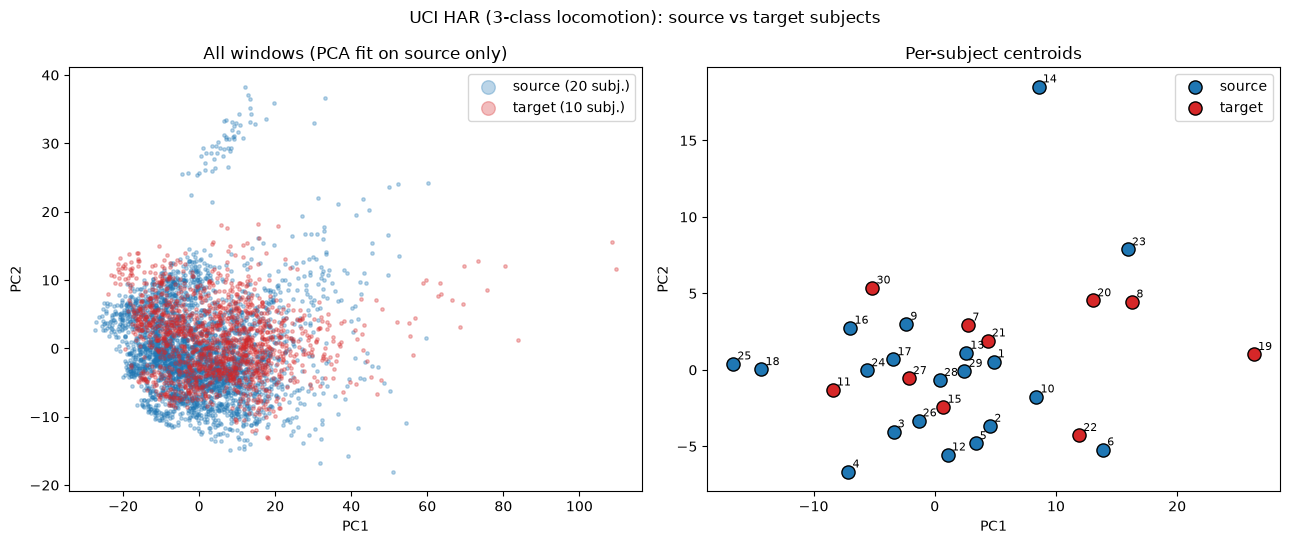


Most-shifted target subject: 19 (distance=29.2101)


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: All windows, source vs target
axes[0].scatter(pc_source[:, 0], pc_source[:, 1], s=6, alpha=0.3,
                c="tab:blue", label=f"source ({len(split.source_subjects)} subj.)")
axes[0].scatter(pc_target[:, 0], pc_target[:, 1], s=6, alpha=0.3,
                c="tab:red", label=f"target ({len(split.target_subjects)} subj.)")
axes[0].set_title("All windows (PCA fit on source only)")
axes[0].legend(markerscale=4)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Panel 2: Per-subject centroids with annotations
# Source subject centroids
for sid in split.source_subjects:
    mask = split.subject_id_source == sid
    c = pc_source[mask].mean(axis=0)
    axes[1].scatter(*c, s=90, c="tab:blue", edgecolors="k")
    axes[1].annotate(str(int(sid)), c, fontsize=8, xytext=(3, 3), textcoords="offset points")

# Target subject centroids
for sid in split.target_subjects:
    mask = ds_target.subject_id == sid
    c = pc_target[mask].mean(axis=0)
    axes[1].scatter(*c, s=90, c="tab:red", edgecolors="k")
    axes[1].annotate(str(int(sid)), c, fontsize=8, xytext=(3, 3), textcoords="offset points")

# Legend
axes[1].scatter([], [], c="tab:blue", s=90, edgecolors="k", label="source")
axes[1].scatter([], [], c="tab:red", s=90, edgecolors="k", label="target")
axes[1].set_title("Per-subject centroids")
axes[1].legend()
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

fig.suptitle("UCI HAR (3-class locomotion): source vs target subjects", fontsize=12)
fig.tight_layout()

plt.show()

print()
print(f"Most-shifted target subject: {hardest} (distance={target_shifts[hardest]:.4f})")

## Summary

| item | result |
|---|---|
| dataset load + validation | `load_har` merges train+test (7352+2947 rows); `validate` reports no NaN/Inf, all values in [-1, 1] |
| subject-wise source/target split | 20 source subjects, 10 target subjects (`split_and_scale`, seed=42); scaler fit on the source pool only |
| shift proxy | centroid distance per target subject (`centroid_distance_shift_proxy`); most-shifted subject identified (19, distance=29.21) |
| near-zero-shift reference | leave-one-subject-out distances within the source pool (mean 12.15), plus a random-window-split sanity check (0.95, as expected near zero) |
| PCA sanity check | source-vs-target separation and per-subject centroids visualized in 2D PCA space (fit on source only) |

Mean target-shift distance (14.54) is only ~1.2x the source pool's own leave-one-subject-out baseline (12.15) -- below the 2x rule of thumb used above, so this raw full-561-feature centroid distance alone shows shift that is present but modest, not dramatic. The random-window-split control (0.95) confirms the near-zero-shift reference itself is sound. Per-subject shift is highly heterogeneous (7.41 to 29.21), which is exactly the variation the rest of the pipeline (per-subject accuracy in §4, epistemic uncertainty in §7) exploits -- this coarse proxy is a starting point for identifying hard subjects, not the final word on how shifted they are.